<a href="https://colab.research.google.com/github/AbdelrahmanMohamed-Fathy/compilers-assignment-2/blob/main/Compilers.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>


# Input and Verification


In [10]:
from pydantic import BaseModel, Field, field_serializer, computed_field
from automata.fa.nfa import NFA, NFAStateT
from typing import Optional, ClassVar
from enum import Enum, StrEnum

# @title reading regex string
regex = input("enter your regex: ")

In [11]:
# @title Function to return the opposite pair of a bracket
def get_pair(bracket: str) -> str:
    match bracket:
        case ")":
            return "("
        case "]":
            return "["
        case _:
            raise ValueError("Received none bracket")

In [12]:
# @title Check for correct brackets using a stack
stack = []
for char in regex:
    # adding to stack if opening a bracket
    if char == "(" or char == "[":
        stack.append(char)
    # popping from stack and checking if matching bracket pair
    elif char == ")" or char == "]":
        if stack.pop() != get_pair(char):
            raise ValueError("Invalid regex")

if len(stack) != 0:
    raise ValueError("Invalid regex")

In [13]:
# @title Regex groups pydantic model


class GroupModifier(StrEnum):
    PLUS = "+"
    STAR = "*"
    QUESTION_MARK = "?"


class GroupType(Enum):
    SEQUENCE = "sequence"
    OR = "or"


class RegexGroup(BaseModel):
    tokens: list["str | RegexGroup"] = Field(default_factory=list)
    type: GroupType = Field(default=GroupType.SEQUENCE)
    modifier: Optional[GroupModifier] = Field(default=None)

    def insert(self, token: str):
        self.tokens.append(token)

    def insert_group(self, group: "RegexGroup"):
        self.tokens.append(group)


In [14]:
# @title Paring regex and seperating into tokens and groups


def check_for_modifier(group: RegexGroup, char: str):
    match char:
        case GroupModifier.PLUS:
            group.modifier = GroupModifier.PLUS
        case GroupModifier.STAR:
            group.modifier = GroupModifier.STAR
        case GroupModifier.QUESTION_MARK:
            group.modifier = GroupModifier.QUESTION_MARK
    return


def parse_regex(regex: str, ignore_brackets: bool = False) -> RegexGroup:
    token_groups: RegexGroup = RegexGroup()
    parse_index: int = 0
    while parse_index < len(regex):
        match regex[parse_index]:
            # Sequence group handling
            case "(" if not ignore_brackets:
                token_groups.insert_group(parse_regex(regex[parse_index + 1 :]))
                parse_index = regex.find(")", parse_index) + 1
                # skip plus and star related to group
                if parse_index < len(regex) and regex[parse_index] in list(
                    GroupModifier
                ):
                    parse_index += 1

            case ")" if not ignore_brackets:
                if parse_index + 1 < len(regex):
                    check_for_modifier(token_groups, regex[parse_index + 1])
                return token_groups
            # Or group handling
            case "[" if not ignore_brackets:
                token_groups.insert_group(
                    parse_regex(regex[parse_index + 1 :], ignore_brackets=True)
                )
                parse_index = regex.find("]", parse_index) + 1
                # skip plus and star related to group
                if parse_index < len(regex) and regex[parse_index] in list(
                    GroupModifier
                ):
                    parse_index += 1
            case "]":
                token_groups.type = GroupType.OR
                if parse_index + 1 < len(regex):
                    check_for_modifier(token_groups, regex[parse_index + 1])
                return token_groups
            # literals handling
            case _:
                if parse_index + 1 < len(regex) and regex[parse_index + 1] == "+":
                    token_groups.insert_group(
                        RegexGroup(
                            tokens=[regex[parse_index]], modifier=GroupModifier.PLUS
                        )
                    )
                    parse_index += 2
                elif parse_index + 1 < len(regex) and regex[parse_index + 1] == "*":
                    token_groups.insert_group(
                        RegexGroup(
                            tokens=[regex[parse_index]], modifier=GroupModifier.STAR
                        )
                    )
                    parse_index += 2
                elif parse_index + 1 < len(regex) and regex[parse_index + 1] == "?":
                    token_groups.insert_group(
                        RegexGroup(
                            tokens=[regex[parse_index]],
                            modifier=GroupModifier.QUESTION_MARK,
                        )
                    )
                    parse_index += 2
                elif parse_index + 1 < len(regex) and regex[parse_index + 1] == "-":
                    token_groups.insert(regex[parse_index : parse_index + 3])
                    parse_index += 3
                else:
                    token_groups.insert(regex[parse_index])
                    parse_index += 1

    return token_groups


token_list = parse_regex(regex)
print(token_list)

tokens=['k', RegexGroup(tokens=['o'], type=<GroupType.SEQUENCE: 'sequence'>, modifier=<GroupModifier.PLUS: '+'>), RegexGroup(tokens=['f', 'F'], type=<GroupType.OR: 'or'>, modifier=<GroupModifier.STAR: '*'>), 't', RegexGroup(tokens=['a'], type=<GroupType.SEQUENCE: 'sequence'>, modifier=<GroupModifier.QUESTION_MARK: '?'>)] type=<GroupType.SEQUENCE: 'sequence'> modifier=None


# Generating NFA


In [15]:
# @title Regex pydantic model


class RegexState(BaseModel):
    _name_counter: ClassVar[int] = 0
    name: str = Field(default="Unnamed")
    is_terminating_state: bool = Field(serialization_alias="isTerminatingState")
    children: dict[str, list["RegexState"]] = Field(
        default_factory=dict,
        serialization_alias="paths",
        exclude_if=lambda paths: not paths,
    )

    def __init__(self, **data):
        super().__init__(**data)
        self.name = f"S{RegexState._name_counter}"
        RegexState._name_counter += 1
        self.is_terminating_state = data["is_terminating_state"]
        self.children = data["children"]

    @field_serializer("children")
    def serialize_children(self, children: dict[str, list["RegexState"]], _info):
        return {k: [node.name for node in v] for k, v in children.items()}


In [16]:
# @title NFA pydantic model


class NfaModel(BaseModel):
    nodes: list[RegexState] = Field(default_factory=list, serialization_alias="States")

    def insert(self, node: RegexState):
        self.nodes.append(node)

    @computed_field(alias="startingState")
    @property
    def starting_node(self) -> str:
        return self.nodes[0].name


In [17]:
# @title Generation handler functions


def general_handler(
    nfa: NfaModel,
    group: RegexGroup,
    is_terminating: bool = False,
    child: tuple[str, list[RegexState]] | None = None,
) -> tuple[RegexState, RegexState]:
    if group.modifier is not None:
        return modifier_handler(
            nfa=nfa, group=group, is_terminating=is_terminating, child=child
        )
    elif group.type == GroupType.SEQUENCE:
        return sequence_handler(
            nfa=nfa, group=group, is_terminating=is_terminating, child=child
        )
    else:
        return or_handler(
            nfa=nfa, group=group, is_terminating=is_terminating, child=child
        )


def sequence_handler(
    nfa: NfaModel,
    group: RegexGroup,
    is_terminating: bool = False,
    child: tuple[str, list[RegexState]] | None = None,
) -> tuple[RegexState, RegexState]:
    initial_node = None
    final_node = None
    node_to_attach = None
    # we simply just loop on each token and keep adding them sequentially and connecting them with every loop
    for index, token in enumerate(group.tokens):
        if isinstance(token, str):
            (first, second) = base_handler(
                nfa=nfa,
                regex=token,
                is_terminating=False
                if index != len(group.tokens) - 1
                else is_terminating,
            )
        else:
            (first, second) = general_handler(
                nfa=nfa,
                group=token,
                is_terminating=False
                if index != len(group.tokens) - 1
                else is_terminating,
            )

        # we attach between sequential nodes here
        if node_to_attach:
            if "Ɛ" not in node_to_attach.children:
                node_to_attach.children["Ɛ"] = []
            node_to_attach.children["Ɛ"].append(first)

        node_to_attach = second

        # marking the initial node for return
        if not initial_node:
            initial_node = first

    # marking the final node as the last assigned node and attaching children if necessary
    final_node = second
    final_node.children = {child[0]: child[1]} if child else final_node.children
    return (initial_node, final_node)  # pyright: ignore[reportReturnType]


def or_handler(
    nfa: NfaModel,
    group: RegexGroup,
    is_terminating: bool = False,
    child: tuple[str, list[RegexState]] | None = None,
) -> tuple[RegexState, RegexState]:
    initial_node = RegexState(is_terminating_state=False, children={"Ɛ": []})
    final_node = RegexState(
        is_terminating_state=is_terminating,
        children={child[0]: child[1]} if child else {},
    )
    nfa.insert(initial_node)
    # handle each indivisually and append it to the initial node while passing the final node as a child to all of them
    for token in group.tokens:
        if isinstance(token, str):
            initial_node.children["Ɛ"].append(
                base_handler(nfa=nfa, regex=token, child=("Ɛ", [final_node]))[0]
            )
        else:
            initial_node.children["Ɛ"].append(
                general_handler(nfa=nfa, group=token, child=("Ɛ", [final_node]))[0]
            )

    nfa.insert(final_node)
    return (initial_node, final_node)


# handling base case of 1 node going to a second node
def base_handler(
    nfa: NfaModel,
    regex: str,
    is_terminating: bool = False,
    child: tuple[str, list[RegexState]] | None = None,
) -> tuple[RegexState, RegexState]:
    first = RegexState(
        is_terminating_state=False,
        children={regex: []},
    )
    second = RegexState(
        is_terminating_state=is_terminating,
        children={child[0]: child[1]} if child else {},
    )
    first.children[regex].append(second)
    nfa.insert(first)
    nfa.insert(second)
    return (first, second)


def modifier_handler(
    nfa: NfaModel,
    group: RegexGroup,
    is_terminating: bool = False,
    child: tuple[str, list[RegexState]] | None = None,
):
    # we store the modifier and remove it from the group so we can give it back to the general handler
    modifier = group.modifier
    group.modifier = None

    # both star and question mark would make this true
    initial_node = RegexState(is_terminating_state=False, children={"Ɛ": []})
    final_node = RegexState(
        is_terminating_state=is_terminating,
        children={child[0]: child[1]} if child else {},
    )

    # now that modifier is removed we can call general handler and apply effects after
    nfa.insert(initial_node)
    (first, second) = general_handler(
        nfa=nfa, group=group, is_terminating=False, child=("Ɛ", [final_node])
    )
    initial_node.children["Ɛ"].append(first)
    nfa.insert(final_node)

    # both of these conditions capture all possibilities
    if modifier != GroupModifier.PLUS:
        initial_node.children["Ɛ"].append(final_node)
    if modifier != GroupModifier.QUESTION_MARK:
        if "Ɛ" not in second.children:
            second.children["Ɛ"] = []
        second.children["Ɛ"].append(first)

    return (initial_node, final_node)

{
  "States": [
    {
      "name": "S0",
      "isTerminatingState": false,
      "paths": {
        "k": [
          "S1"
        ]
      }
    },
    {
      "name": "S1",
      "isTerminatingState": false,
      "paths": {
        "Ɛ": [
          "S2"
        ]
      }
    },
    {
      "name": "S2",
      "isTerminatingState": false,
      "paths": {
        "Ɛ": [
          "S4"
        ]
      }
    },
    {
      "name": "S4",
      "isTerminatingState": false,
      "paths": {
        "o": [
          "S5"
        ]
      }
    },
    {
      "name": "S5",
      "isTerminatingState": false,
      "paths": {
        "Ɛ": [
          "S3",
          "S4"
        ]
      }
    },
    {
      "name": "S3",
      "isTerminatingState": false,
      "paths": {
        "Ɛ": [
          "S6"
        ]
      }
    },
    {
      "name": "S6",
      "isTerminatingState": false,
      "paths": {
        "Ɛ": [
          "S8",
          "S7"
        ]
      }
    },
    {
      "name": "

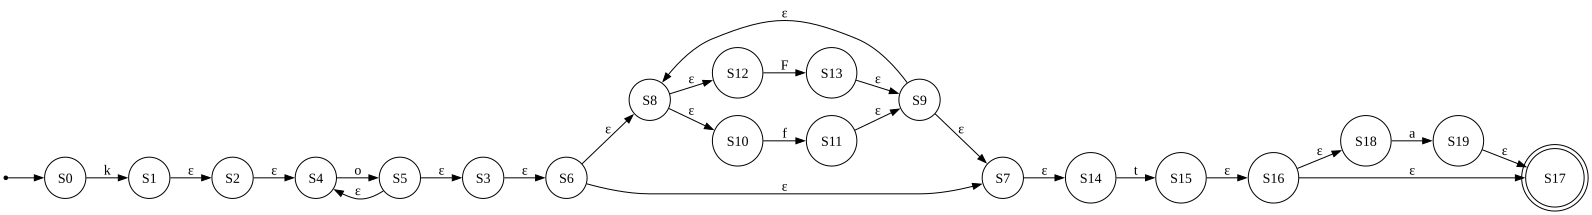

In [18]:
# @title Calling the method to create NFA
nfa: NfaModel = NfaModel()
general_handler(nfa=nfa, group=token_list, is_terminating=True)
print(nfa.model_dump_json(by_alias=True, indent=2))

states = set([node.name for node in nfa.nodes])
final_states = set([node.name for node in nfa.nodes if node.is_terminating_state])
initial_state = nfa.starting_node
input_symbols: set[str] = set({})
[
    input_symbols.update([key for key in node.children.keys() if key != "Ɛ"])
    for node in nfa.nodes
]
transitions = {
    node.name: {
        key if key != "Ɛ" else "": set([state.name for state in path])
        for key, path in node.children.items()
    }
    for node in nfa.nodes
    if len(node.children) > 0
}

print(f"symbols = {input_symbols}")
print(f"transitions = {transitions}")

graph = NFA(
    states=states,
    input_symbols=input_symbols,
    transitions=transitions,
    initial_state=initial_state,
    final_states=final_states,
)

graph.show_diagram()

# Optimizing into DFA
